# iPTM Comparison: cmpnn vs original (PDL1 cyclic peptide binder)

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

## Reusable function: plot iPTM from a single CSV path

In [6]:
def plot_iptm_summary(csv_path):
    """Plot per-run best iPTM boxplot and iPTM per-run line plot from a summary CSV."""
    import os, re
    df = pd.read_csv(csv_path)
    iptm_cols = sorted(
        [c for c in df.columns if re.match(r'cycle_\d+_iptm', c)],
        key=lambda c: int(re.search(r'(\d+)', c).group(1))
    )
    iptm_arr = df[iptm_cols].values.astype(float)
    max_iptm = np.nanmax(iptm_arr, axis=1)
    best_run_idx = np.nanargmax(max_iptm)
    name = os.path.basename(os.path.dirname(csv_path))
    model = os.path.basename(os.path.dirname(os.path.dirname(csv_path))).split('_')[-1]

    fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))

    # Left: boxplot of per-run max iPTM
    ax = axes[0]
    bp = ax.boxplot([max_iptm], labels=[name], patch_artist=True, widths=0.4)
    bp['boxes'][0].set_facecolor('#3498DB')
    bp['boxes'][0].set_alpha(0.4)
    x = np.random.normal(1, 0.04, size=len(max_iptm))
    ax.scatter(x, max_iptm, alpha=0.7, color='#3498DB', s=50, zorder=5, edgecolors='white', linewidth=0.5)
    # Highlight best run
    ax.scatter(x[best_run_idx], max_iptm[best_run_idx], color='#E74C3C', s=120, zorder=6,
               edgecolors='black', linewidth=1.2, marker='*')
    ax.annotate(f'run {best_run_idx}\n{max_iptm[best_run_idx]:.4f}',
                xy=(x[best_run_idx], max_iptm[best_run_idx]),
                xytext=(15, 5), textcoords='offset points', fontsize=9, color='#E74C3C',
                arrowprops=dict(arrowstyle='->', color='#E74C3C', lw=1.2))
    ax.set_ylabel('Max iPTM per run', fontsize=12)
    ax.set_title(f'{model} Per-run Best iPTM ({name})', fontsize=12, pad=15)
    ax.grid(True, alpha=0.3, linestyle='--', axis='y')
    ax.spines[['top', 'right']].set_visible(False)
    ax.annotate(f'mean={np.nanmean(max_iptm):.3f}\nmax={np.nanmax(max_iptm):.3f}',
                xy=(0.95, 0.95), xycoords='axes fraction', ha='right', va='top', fontsize=10)

    # Right: per-run iPTM trajectories
    ax = axes[1]
    for i in range(iptm_arr.shape[0]):
        ax.plot(iptm_arr[i], alpha=0.4, linewidth=1.2, color='#3498DB')
    # Highlight best run
    ax.plot(iptm_arr[best_run_idx], color='#E74C3C', linewidth=2.5, alpha=1.0, label=f'best: run {best_run_idx}')
    best_cycle = np.nanargmax(iptm_arr[best_run_idx])
    ax.scatter(best_cycle, iptm_arr[best_run_idx, best_cycle], color='#E74C3C', s=100, zorder=6,
               edgecolors='black', linewidth=1.2, marker='*')
    ax.annotate(f'{max_iptm[best_run_idx]:.4f}',
                xy=(best_cycle, iptm_arr[best_run_idx, best_cycle]),
                xytext=(8, 8), textcoords='offset points', fontsize=9, color='#E74C3C',
                arrowprops=dict(arrowstyle='->', color='#E74C3C', lw=1.2))
    ax.set_xlabel('Cycle', fontsize=12)
    ax.set_ylabel('iPTM', fontsize=12)
    ax.set_title(f'{model} iPTM per Run ({name})', fontsize=12, pad=15)
    ax.legend(fontsize=10, loc='lower right')
    ax.grid(True, alpha=0.3, linestyle='--')
    ax.spines[['top', 'right']].set_visible(False)

    plt.tight_layout()
    plt.show()
    print(f"{name}: {iptm_arr.shape[0]} runs, {iptm_arr.shape[1]} cycles | max iPTM mean={np.nanmean(max_iptm):.4f}, best={np.nanmax(max_iptm):.4f} (run {best_run_idx}, cycle {best_cycle})")

/tmp/ipykernel_3253254/151962312.py:19: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot([max_iptm], labels=[name], patch_artist=True, widths=0.4)


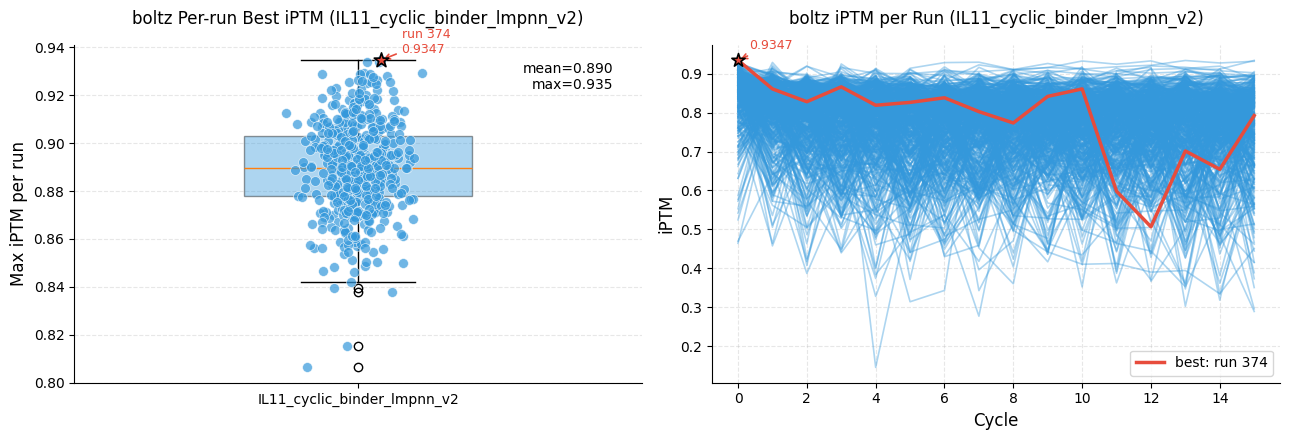

IL11_cyclic_binder_lmpnn_v2: 505 runs, 16 cycles | max iPTM mean=0.8898, best=0.9347 (run 374, cycle 0)


In [8]:
# # Example usage:
path = '/home/xchen/projects/Protein-Hunter/results_boltz/IL11_cyclic_binder_lmpnn_v2/summary_all_runs.csv'
plot_iptm_summary(path)
# path = '/home/xchen/projects/Protein-Hunter/results_boltz/IL11_cyclic_binder_denovo_lmpnn_v3/summary_all_runs.csv'
# plot_iptm_summary(path)

/tmp/ipykernel_3253254/151962312.py:19: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot([max_iptm], labels=[name], patch_artist=True, widths=0.4)


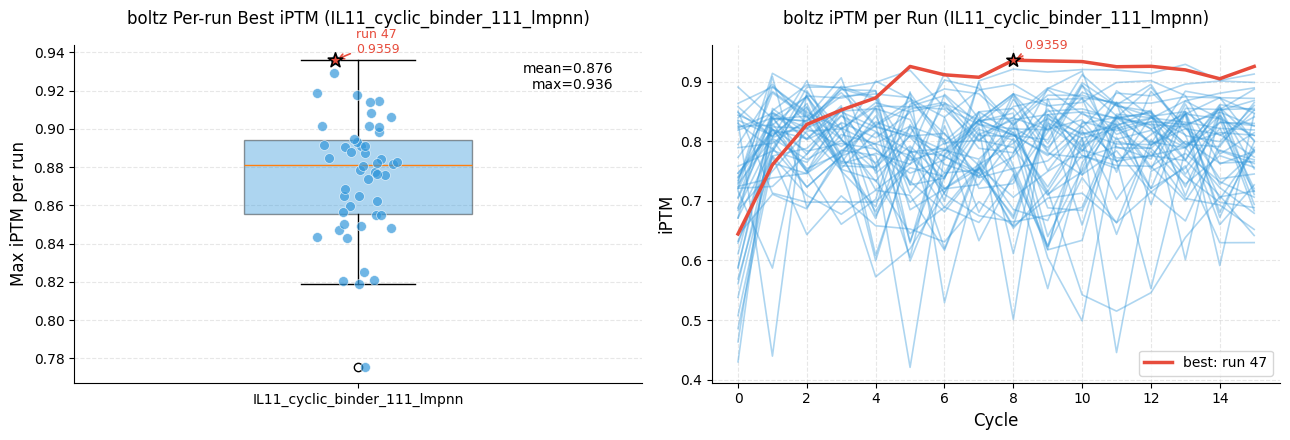

IL11_cyclic_binder_111_lmpnn: 50 runs, 16 cycles | max iPTM mean=0.8756, best=0.9359 (run 47, cycle 8)


/tmp/ipykernel_3253254/151962312.py:19: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot([max_iptm], labels=[name], patch_artist=True, widths=0.4)


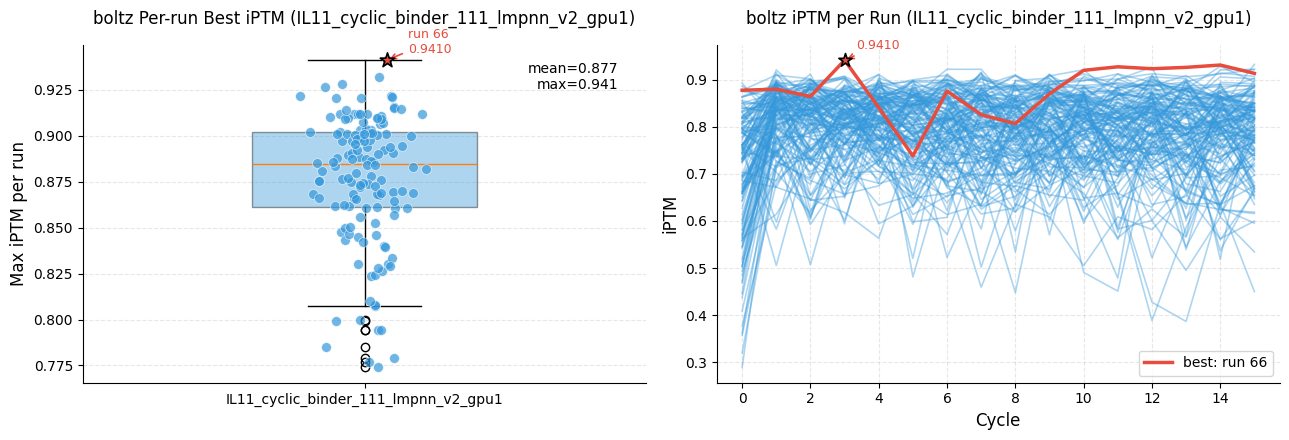

IL11_cyclic_binder_111_lmpnn_v2_gpu1: 140 runs, 16 cycles | max iPTM mean=0.8769, best=0.9410 (run 66, cycle 3)


/tmp/ipykernel_3253254/151962312.py:19: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot([max_iptm], labels=[name], patch_artist=True, widths=0.4)


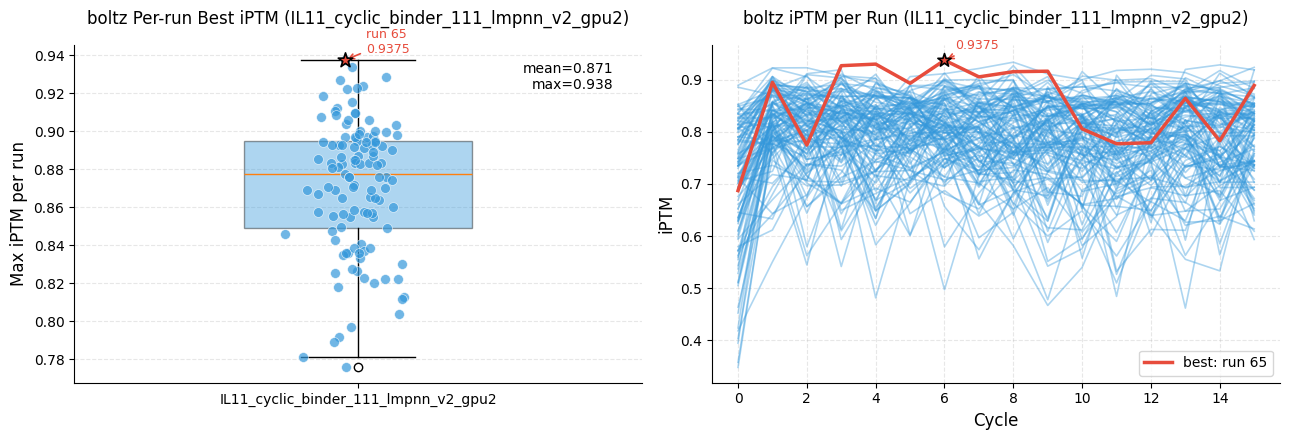

IL11_cyclic_binder_111_lmpnn_v2_gpu2: 117 runs, 16 cycles | max iPTM mean=0.8712, best=0.9375 (run 65, cycle 6)


/tmp/ipykernel_3253254/151962312.py:19: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot([max_iptm], labels=[name], patch_artist=True, widths=0.4)


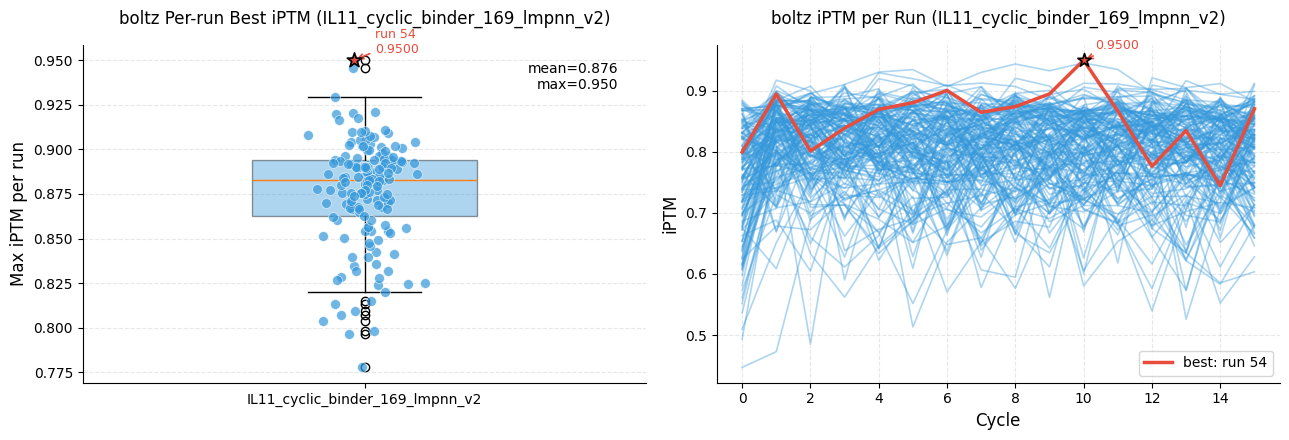

IL11_cyclic_binder_169_lmpnn_v2: 156 runs, 16 cycles | max iPTM mean=0.8761, best=0.9500 (run 54, cycle 10)


/tmp/ipykernel_3253254/151962312.py:19: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot([max_iptm], labels=[name], patch_artist=True, widths=0.4)


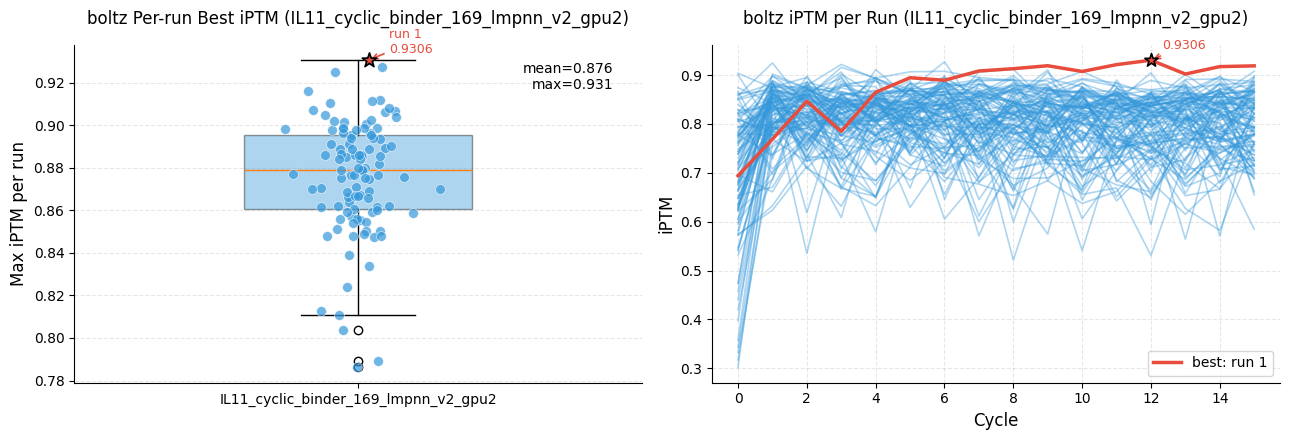

IL11_cyclic_binder_169_lmpnn_v2_gpu2: 105 runs, 16 cycles | max iPTM mean=0.8760, best=0.9306 (run 1, cycle 12)


/tmp/ipykernel_3253254/151962312.py:19: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot([max_iptm], labels=[name], patch_artist=True, widths=0.4)


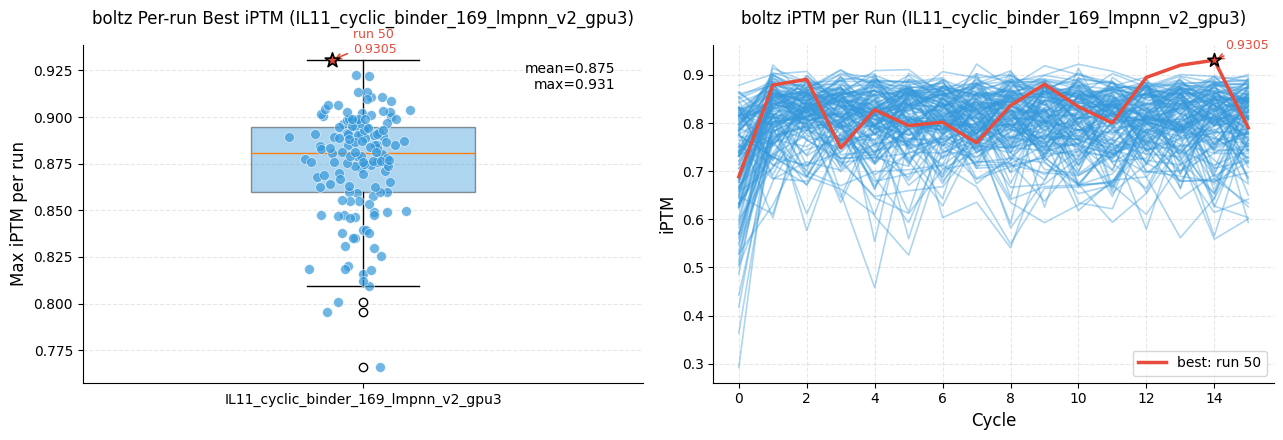

IL11_cyclic_binder_169_lmpnn_v2_gpu3: 140 runs, 16 cycles | max iPTM mean=0.8748, best=0.9305 (run 50, cycle 14)


In [9]:
path = '/home/xchen/projects/Protein-Hunter/results_boltz/IL11_cyclic_binder_111_lmpnn/summary_all_runs.csv'
plot_iptm_summary(path)
path = '/home/xchen/projects/Protein-Hunter/results_boltz/IL11_cyclic_binder_111_lmpnn_v2_gpu1/summary_all_runs.csv'
plot_iptm_summary(path)
path = '/home/xchen/projects/Protein-Hunter/results_boltz/IL11_cyclic_binder_111_lmpnn_v2_gpu2/summary_all_runs.csv'
plot_iptm_summary(path)
path = '/home/xchen/projects/Protein-Hunter/results_boltz/IL11_cyclic_binder_169_lmpnn_v2/summary_all_runs.csv'
plot_iptm_summary(path)
path = '/home/xchen/projects/Protein-Hunter/results_boltz/IL11_cyclic_binder_169_lmpnn_v2_gpu2/summary_all_runs.csv'
plot_iptm_summary(path)
path = '/home/xchen/projects/Protein-Hunter/results_boltz/IL11_cyclic_binder_169_lmpnn_v2_gpu3/summary_all_runs.csv'
plot_iptm_summary(path)

In [ ]:
# AI WROTE THIS USE WITH CAUTION
def get_high_iptm_structures(csv_path, threshold=0.8):
    """
    Given a summary_all_runs.csv path, return a DataFrame of all (run, cycle) entries
    with iPTM above the threshold, along with reconstructed structure file paths.
    
    Returns DataFrame with columns: run_id, cycle, iptm, plddt, iplddt, pae, seq, pdb_path,
        and unconditioned metrics if available: uncond_iptm, uncond_plddt, uncond_iplddt, uncond_pae
    """
    import os, re
    df = pd.read_csv(csv_path)
    base_dir = os.path.dirname(csv_path)
    jobname = os.path.basename(base_dir)
    
    # Detect if boltz or chai based on directory structure
    is_boltz = 'results_boltz' in csv_path
    
    # Check if unconditioned metrics exist
    has_uncond = 'best_uncond_iptm' in df.columns
    
    iptm_cols = sorted(
        [c for c in df.columns if re.match(r'cycle_\d+_iptm', c)],
        key=lambda c: int(re.search(r'(\d+)', c).group(1))
    )
    
    rows = []
    for _, row in df.iterrows():
        run_id = int(row['run_id'])
        for col in iptm_cols:
            val = row[col]
            if pd.isna(val) or val < threshold:
                continue
            cycle = int(re.search(r'(\d+)', col).group(1))
            seq_col = f'cycle_{cycle}_seq'
            plddt_col = f'cycle_{cycle}_plddt'
            iplddt_col = f'cycle_{cycle}_iplddt'
            seq = row.get(seq_col, '')
            plddt = row.get(plddt_col, np.nan)
            iplddt = row.get(iplddt_col, np.nan)
            
            # Reconstruct path
            if is_boltz:
                pdb_path = os.path.join(
                    base_dir, '0_protein_hunter_design', f'run_{run_id}',
                    f'{jobname}_run_{run_id}_predicted_cycle_{cycle}.pdb'
                )
            else:
                pdb_path = os.path.join(base_dir, f'run_{run_id}', f'cycle_{cycle}.cif')
            
            entry = {
                'run_id': run_id,
                'cycle': cycle,
                'iptm': val,
                'plddt': plddt,
                'iplddt': iplddt,
                'seq': seq,
                'pdb_path': pdb_path,
            }
            
            # Add unconditioned metrics (only for the best cycle of this run)
            if has_uncond and cycle == row.get('best_cycle', -1):
                entry['uncond_iptm'] = row.get('best_uncond_iptm', np.nan)
                entry['uncond_plddt'] = row.get('best_uncond_plddt', np.nan)
                entry['uncond_iplddt'] = row.get('best_uncond_iplddt', np.nan)
                entry['uncond_pae'] = row.get('best_uncond_pae', np.nan)
            else:
                entry['uncond_iptm'] = np.nan
                entry['uncond_plddt'] = np.nan
                entry['uncond_iplddt'] = np.nan
                entry['uncond_pae'] = np.nan
            
            rows.append(entry)
    
    result = pd.DataFrame(rows).sort_values('iptm', ascending=False).reset_index(drop=True)
    print(f"{len(result)} structures above iPTM {threshold} from {jobname}")
    return result

In [11]:
def plot_results(plot_df):
    fig, ax = plt.subplots(figsize=(6, 6))
    ax.scatter(plot_df['iptm'], plot_df['uncond_iptm'], alpha=0.7, s=60, edgecolors='white', linewidth=0.5)

    lo = min(plot_df['iptm'].min(), plot_df['uncond_iptm'].min()) - 0.01
    hi = max(plot_df['iptm'].max(), plot_df['uncond_iptm'].max()) + 0.01
    ax.plot([lo, hi], [lo, hi], '--', color='gray', alpha=0.6, label='y=x')
    ax.set_xlim(lo, hi)
    ax.set_ylim(lo, hi)

    ax.set_xlabel('Conditioned iPTM', fontsize=12)
    ax.set_ylabel('Unconditioned iPTM', fontsize=12)
    ax.set_title(f'Unconditioned vs Conditioned iPTM (n={len(plot_df)})', fontsize=13)
    ax.legend(fontsize=10)
    ax.grid(True, alpha=0.3, linestyle='--')
    ax.spines[['top', 'right']].set_visible(False)
    plt.tight_layout()
    plt.show()

In [15]:
folders_169 = ['IL11_cyclic_binder_169_lmpnn_v2', 'IL11_cyclic_binder_169_lmpnn_v2_gpu2', 'IL11_cyclic_binder_169_lmpnn_v2_gpu3']
res_169 = []
res_169_unfiltered = []
for folder in folders_169:
    path = f'/home/xchen/projects/Protein-Hunter/results_boltz/{folder}/summary_all_runs.csv'
    res_169.append(get_high_iptm_structures(path, threshold=0.9))
    res_169_unfiltered.append(get_high_iptm_structures(path, threshold=0.0))
res_169_unfiltered_df = pd.concat(res_169_unfiltered, axis=0)
res_169_df = pd.concat(res_169, axis=0)

61 structures above iPTM 0.9 from IL11_cyclic_binder_169_lmpnn_v2
2496 structures above iPTM 0.0 from IL11_cyclic_binder_169_lmpnn_v2
29 structures above iPTM 0.9 from IL11_cyclic_binder_169_lmpnn_v2_gpu2
1680 structures above iPTM 0.0 from IL11_cyclic_binder_169_lmpnn_v2_gpu2
33 structures above iPTM 0.9 from IL11_cyclic_binder_169_lmpnn_v2_gpu3
2240 structures above iPTM 0.0 from IL11_cyclic_binder_169_lmpnn_v2_gpu3


In [13]:
folders_111 = ['IL11_cyclic_binder_111_lmpnn_v2_gpu1', 'IL11_cyclic_binder_111_lmpnn_v2_gpu2']
res_111 = []
res_111_unfiltered = []

for folder in folders_111:
    path = f'/home/xchen/projects/Protein-Hunter/results_boltz/{folder}/summary_all_runs.csv'
    res_111.append(get_high_iptm_structures(path, threshold=.9))
    res_111_unfiltered.append(get_high_iptm_structures(path, threshold=.0))
res_111_df = pd.concat(res_111, axis=0)
res_111_unfiltered_df = pd.concat(res_111_unfiltered, axis=0)

80 structures above iPTM 0.9 from IL11_cyclic_binder_111_lmpnn_v2_gpu1
2240 structures above iPTM 0.0 from IL11_cyclic_binder_111_lmpnn_v2_gpu1
61 structures above iPTM 0.9 from IL11_cyclic_binder_111_lmpnn_v2_gpu2
1872 structures above iPTM 0.0 from IL11_cyclic_binder_111_lmpnn_v2_gpu2


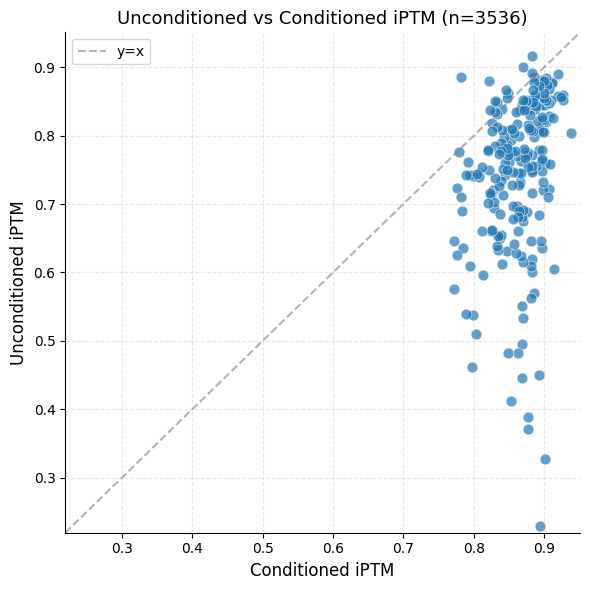

In [ ]:
plot_results(res_111_unfiltered_df)

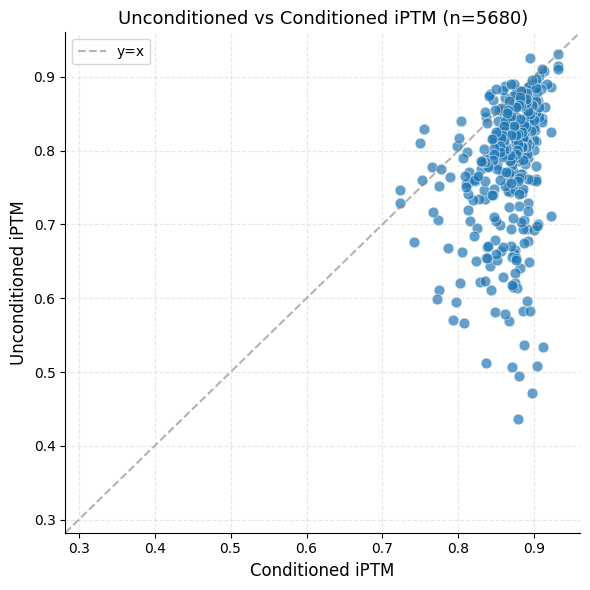

In [ ]:
plot_results(res_169_unfiltered_df)